### Import and Setup

In [1]:
# Import PyTorch core modules for model building and training
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import re # Import regex for text tokenization

from collections import Counter # Counter is used to count token frequency for vocabulary construction
from datasets import load_dataset

### Load Dataset

In [2]:
dataset = load_dataset("imdb")  # Load the IMDB movie review dataset

train_data = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_split = train_data["train"]
val_split = train_data["test"]
# Split the original training set into training and validation subsets

test_split = dataset["test"]  # Split the original training set into training and validation subsets

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Tokenizer

In [3]:
def tokenize(word):
    word = word.lower()
    return re.findall(r"\b\w+\b", word)
# Convert text to lowercase and split into word tokens
# This removes punctuation and keeps only alphanumeric word pieces

### Build Vocabulary

In [4]:
token_counter = Counter()
#Count token frequencies from the training split only, which will be used later to build the vocabulary

for i in range(len(train_split)):
    tokens = tokenize(train_split[i]["text"])
    token_counter.update(tokens)

### Numericalization + Padding

In [5]:
def numericalize(tokens):
    return [vocab.get(t, vocab["<unk>"]) for t in tokens]
# Convert tokens into integer IDs using the vocabulary
# Unknown tokens are mapped to the <unk> token

def pad_sequence(seq, max_len=300):
    seq = seq[:max_len]
    if len(seq) < max_len:
        seq = seq + [vocab["<pad>"]] * (max_len - len(seq))
    return seq
# Pad or truncate each sequence to a fixed length
# This ensures all reviews have the same input size for the GRU model

### Custom Dataset Class

In [6]:
class IMDBDataset(Dataset): #Create a custom PyTorch dataset for IMDB Reviews
    def __init__(self, split):
        self.data = split

    def __len__(self):
        return len(self.data)
    # Return total number of examples in the split

    def __getitem__(self, idx):
        text = self.data[idx]["text"]
        label = self.data[idx]["label"]
    # Convert one review into padded token IDs and return its label

        tokens = tokenize(text) #Tokenize the raw text
        ids = numericalize(tokens)  #Convert tokens into vocabulary IDs
        ids = pad_sequence(ids) #Pad the sequence to fixed length

        return torch.tensor(ids), torch.tensor(label)


train_dataset = IMDBDataset(train_split)
val_dataset = IMDBDataset(val_split)
test_dataset = IMDBDataset(test_split)
# Create dataset objects for training, validation, and testing

### Data Loader

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)
# Create PyTorch DataLoaders for batching and shuffling data
# Training loader uses shuffle=True to improve training randomness

### GRU Model

In [8]:
class GRUModelClassifier(nn.Module): # Define a GRU-based text classification model
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.GRU = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        self.fclayer = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x) # Convert token IDs to embeddings
        out, h = self.GRU(x)  # Pass embeddings through the GRU
        return self.fclayer(h[-1]) #  Use the final hidden state for classification

### Training Setup

In [9]:
min_freq = 5 # Keep tokens that appear more than the minimum frequency threshold

special_tokens = ["<unk>", "<pad>"] # Keep tokens that appear more than the minimum frequency threshold

filtered_tokens = [token for token, count in token_counter.items() if count > min_freq]
vocab = {token: i for i, token in enumerate(special_tokens + filtered_tokens)}
# Build the vocabulary from filtered training tokens

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use GPU if available, otherwise fall back to CPU

model = GRUModelClassifier(len(vocab), 128, 128).to(device) # Initialize the GRU model

criterion = nn.CrossEntropyLoss() # CrossEntropyLoss is suitable for 2-class classification with logits output

optimizer = optim.Adam(model.parameters(), lr=1e-3) # Adam optimizer is used for training

### Train and Evaluate

In [10]:
def train_epoch(model, loader): # Train the model for one epoch
    model.train()
    total, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device) # Move input batch and labels to the selected device

        optimizer.zero_grad() # Reset gradients from the previous step

        preds = model(x)  # Forward Pass

        loss = criterion(preds, y)  # Compute classification loss

        loss.backward()  # Backward Pass

        optimizer.step()  # Update model parameters

        predicted = preds.argmax(1)  # Convert logits to predicted class index

        correct += (predicted == y).sum().item()
        total += y.size(0)
         # Accumulate correct predictions

    return correct / total

def evaluate(model, loader):  # Evaluate the model without updating weights
    model.eval()
    total, correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device) # Move data to the selected device

            preds = model(x)  #Forward pass

            predicted = preds.argmax(1) # Convert logits to predicted class index

            correct += (predicted == y).sum().item()
            total += y.size(0)
            # Accumulate accuracy counts

    return correct / total

for epoch in range(10): # Train the model for multiple epochs and monitor validation accuracy
    train_accuracy = train_epoch(model, train_loader)
    validation_accuracy = evaluate(model, validation_loader)
    test_accuracy = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}: Train Acc = {train_accuracy:.4f}, Validation Acc = {validation_accuracy:.4f},  Test Acc = {test_accuracy:.4f}")

Epoch 1: Train Acc = 0.5035, Validation Acc = 0.5076,  Test Acc = 0.5051
Epoch 2: Train Acc = 0.5528, Validation Acc = 0.6576,  Test Acc = 0.6505
Epoch 3: Train Acc = 0.7725, Validation Acc = 0.8358,  Test Acc = 0.8212
Epoch 4: Train Acc = 0.8863, Validation Acc = 0.8578,  Test Acc = 0.8367
Epoch 5: Train Acc = 0.9395, Validation Acc = 0.8662,  Test Acc = 0.8514
Epoch 6: Train Acc = 0.9696, Validation Acc = 0.8734,  Test Acc = 0.8537
Epoch 7: Train Acc = 0.9826, Validation Acc = 0.8634,  Test Acc = 0.8467
Epoch 8: Train Acc = 0.9903, Validation Acc = 0.8638,  Test Acc = 0.8449
Epoch 9: Train Acc = 0.9952, Validation Acc = 0.8626,  Test Acc = 0.8448
Epoch 10: Train Acc = 0.9944, Validation Acc = 0.8660,  Test Acc = 0.8505


## GRU Table

In [11]:
import pandas as pd

# Create a table for GRU parameter details and results
gru_results_df = pd.DataFrame([
    {
        "Experiment": "Experiment 1",
        "Model": "GRU",
        "Dataset": "IMDB",
        "Learning Rate": 0.001,
        "Batch Size": 64,
        "Epochs": 10,
        "Embedding Dim": 128,
        "GRU Units": 64,
        "Max Length": 200,
        "Optimizer": "Adam",
        "Loss Function": "Binary Crossentropy",
        "Best Validation Accuracy": 0.8784,
        "Test Accuracy": 0.8467
    }
])


gru_results_df.to_csv("GRU_Evaluation_Table.csv", index=False)  # Save the table as a CSV file

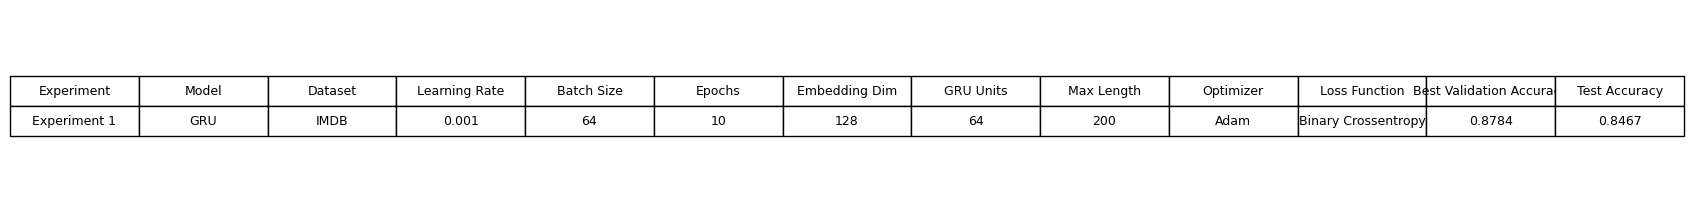

In [12]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(18, 2.5))
ax.axis("off")

# Add table
table = ax.table(
    cellText=gru_results_df.values,
    colLabels=gru_results_df.columns,
    loc="center",
    cellLoc="center"
)

# Adjust font and scaling
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Save as PDF
plt.savefig("GRU_Evaluation_Table.jpg", bbox_inches="tight")
plt.show()

## Sentiment Prediction on IMDB Test Samples

In [13]:
# Predict sentiment for one review
def predict_review(text):
    tokens = tokenize(text)
    ids = numericalize(tokens)
    ids = pad_sequence(ids)
    x = torch.tensor([ids]).to(device)

    model.eval()
    with torch.no_grad():
        output = model(x)
        prediction = torch.argmax(output, dim=1).item()

    return prediction

# Take a few examples from the test set
for i in range(3):
    sample_text = test_split[i]["text"]
    true_label = test_split[i]["label"]
    pred_label = predict_review(sample_text)

    true_sentiment = "Positive" if true_label == 1 else "Negative"
    predicted_sentiment = "Positive" if pred_label == 1 else "Negative"

    print(f"Sample {i+1}")
    print("Review:", sample_text[:300], "...")
    print("True Label:", true_sentiment)
    print("Predicted Label:", predicted_sentiment)
    print("-" * 60)

Sample 1
Review: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, C ...
True Label: Negative
Predicted Label: Negative
------------------------------------------------------------
Sample 2
Review: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. All of this is entertaining and competently handled bu ...
True Label: Negative
Predicted Label: Negative
------------------------------------------------------------
Sample 3
Review: its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the 